In [40]:
# Group 3 - Task 5: Options (II) - Monte Carlo Simulation (Straddle)

# Tom Jilg, Lena Bahati, Benita Bullatovic, Tsvetelin Naydenov, Lisa Singer, Leonardo Sitzia

import numpy as np  # for numerical computations
import matplotlib.pyplot as plt  # for plotting
from IPython.display import display, Markdown  # render tables

np.random.seed(100)  # for reproducibility


# Task 5: Options (II) - Monte Carlo Simulation

### What is a (long) straddle?

A **long straddle** is an option strategy that combines two long positions:

* one long call: the right to *buy* the underlying at strike price $K$
* one long put: the right to *sell* the underlying at strike price $K$

Both options share the same strike price $K$ and the same maturity $T$.
European-style options are assumed, i.e. exercise is only possible at maturity $T$.

### Payoff structure

The straddle payoff at maturity is

$$\text{Payoff} = |S_T - K|$$

* if $S_T > K$: the call pays $S_T - K$, the put expires worthless
* if $S_T < K$: the put pays $K - S_T$, the call expires worthless
* if $S_T = K$: both options expire worthless, so the payoff is zero

The profit also subtracts the premium paid for entering the position:

$$\text{Profit} = \text{Payoff} - \text{Premium}$$

Therefore, the maximum loss occurs at $S_T = K$ and equals the paid premium.

### Economic interpretation

A straddle is a bet on a large price move in either direction. It is
profitable when the realised move is large enough and loses money when the
price stays close to the strike at maturity. The position is therefore
long volatility rather than directional. A typical use case is a stock facing 
a major binary event within the year. For example a regulatory decision or a merger, 
where large price moves are expected but the direction is uncertain.

### Profit structure

The plot below sketches the profit of a long straddle at maturity, with the
premium already subtracted: a V-shape with the maximum loss at the strike $K$
and two break-even points at $K \pm \text{premium}$. The fully computed version
with the simulated premium follows in Task 5.4.


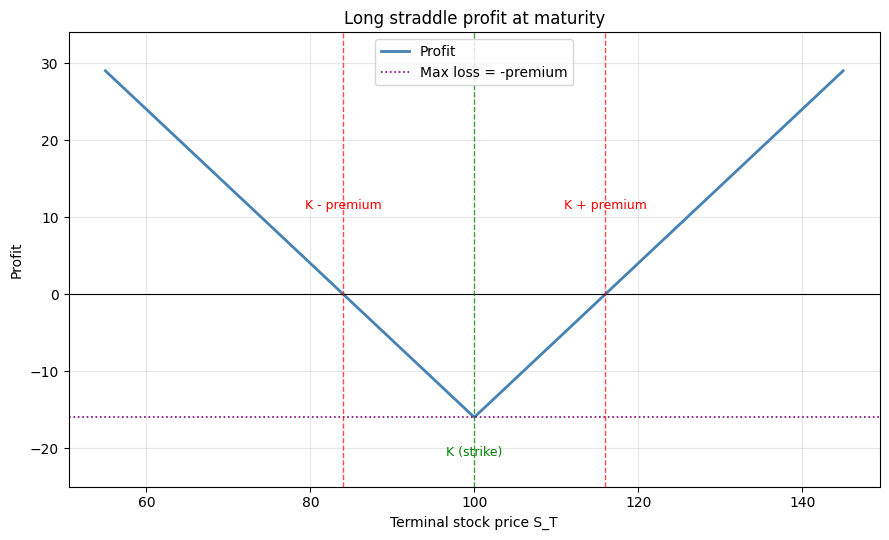

In [41]:
# Schematic long-straddle profit at maturity

# illustrative values only; the exact premium is computed in Task 5.4
k_demo = 100.0          # strike
premium_demo = 16.0     # premium for the straddle

s_grid = np.linspace(k_demo - 45, k_demo + 45, 400)  # grid terminal prices
profit = np.abs(s_grid - k_demo) - premium_demo  # |S_T - K| - premium

lower_be = k_demo - premium_demo  # lower break-even point
upper_be = k_demo + premium_demo  # upper break-even point

fig, ax = plt.subplots(figsize=(9, 5.5))  # figure and axis for plotting
ax.plot(s_grid, profit, linewidth=2, color="steelblue",
        label="Profit")  # V-shaped profit curve
ax.axhline(0, color="black", linewidth=0.8)  # zero profit line
ax.axhline(-premium_demo, color="purple", linewidth=1.2, linestyle=":",
           label="Max loss = -premium")  # maximum loss line
# strike marker
ax.axvline(k_demo, color="green", linestyle="--",
           linewidth=1, alpha=0.7)  # vertical line at strike price
ax.annotate("K (strike)", xy=(k_demo, -premium_demo),
            xytext=(k_demo, -premium_demo - 5), ha="center",
            color="green", fontsize=9)  # text annotation for strike price

# break-even markers
for be, txt in [(lower_be, "K - premium"), (upper_be, "K + premium")]:
    ax.axvline(be, color="red", linestyle="--",
               linewidth=1, alpha=0.7)  # vertical line at break-even points
    ax.annotate(txt, xy=(be, 0), xytext=(be, 11), ha="center",
                color="red", fontsize=9)  # text for break-even points

ax.set_ylim(-premium_demo - 9, profit.max() + 5)  # y-axis range
ax.set_title("Long straddle profit at maturity")  # title of the plot
ax.set_xlabel("Terminal stock price S_T")  # x-axis label
ax.set_ylabel("Profit")  # y-axis label
ax.legend(loc="upper center")  # legend for the plot
ax.grid(True, alpha=0.3)  # add grid for readability
plt.tight_layout()  # auto-adjust spacing
plt.show()  # display the plot


### Note on the premium

The straddle premium is not assumed but computed by Monte Carlo
simulation in Tasks 5.3 and 5.4 as the discounted expected payoff.

## Task 5.1: Simulating GBM paths

The function `sim_gbm()` simulates random asset price paths that follow a
**Geometric Brownian Motion (GBM).** This is the standard model for stock price
dynamics and the basis of the Black–Scholes framework.

The discrete-time GBM step is:

$$S_{t+dt} = S_t \cdot \exp\!\Big(\big(\mu - \tfrac{\sigma^2}{2}\big)\,dt
+ \sigma\,\varepsilon\,\sqrt{dt}\Big)$$

where
- $\mu$: annual drift rate of the price process
- $\sigma$: annual volatility (strength of the random fluctuations)
- $dt$: length of one time step in years
- $\varepsilon \sim N(0,1)$: standard-normal random shock

For option pricing under the risk-neutral measure the drift $\mu$ is
replaced by the risk-free rate $r$ (see Task 5.3).

The function returns a matrix whose rows are time steps (including
$t=0$ and $t=T$) and whose columns are the individual simulated paths.


In [42]:


def sim_gbm(s0, mu, sigma, t_horizon, dt, n_paths):
    """
    Simulate asset price paths using Geometric Brownian Motion (GBM).

    s0        : initial stock price
    mu        : annual drift (expected return)
    sigma     : annual volatility
    t_horizon : time horizon in years
    dt        : length of one time step in years
    n_paths   : number of simulated paths

    Returns a matrix of shape (n_steps + 1, n_paths):
    rows = time steps, columns = simulated paths.
    """
    n_steps = round(t_horizon / dt)  # calculate total number of time steps

    paths = np.zeros((n_steps + 1, n_paths))  # initialise empty path matrix
    paths[0] = s0  # set start price for all paths

    for t in range(1, n_steps + 1):  # loop over time steps
        epsilon = np.random.standard_normal(n_paths)  # N(0,1) shocks
        drift = (mu - 0.5 * sigma ** 2) * dt  # deterministic part of GBM
        diffusion = sigma * epsilon * np.sqrt(dt)  # stochastic part of GBM
        paths[t] = paths[t - 1] * np.exp(drift + diffusion)  # GBM step

    return paths




## Task 5.2: Illustration of the Monte Carlo approach

To show how the simulation behaves, three sample paths are generated and
plotted over time. The simulation is then verified by comparing two
quantities at each time step:

- the cross-sectional average of all simulated paths
- the analytical expectation $E[S_t] = S_0 \cdot \exp(\mu t)$

If the implementation is correct, the average of many paths converges to
the analytical expectation. This serves as a sanity check for `sim_gbm()`.

A real-world drift $\mu = 7\%$ is used here. Task 5.2 shows the
general GBM dynamics, whereas the risk-neutral drift $r$ enters only in the
valuation step (Task 5.3).


paths matrix shape (steps+1, paths): (253, 10000)
after 1y: simulated mean = 107.35 EUR, analytical = 107.25 EUR


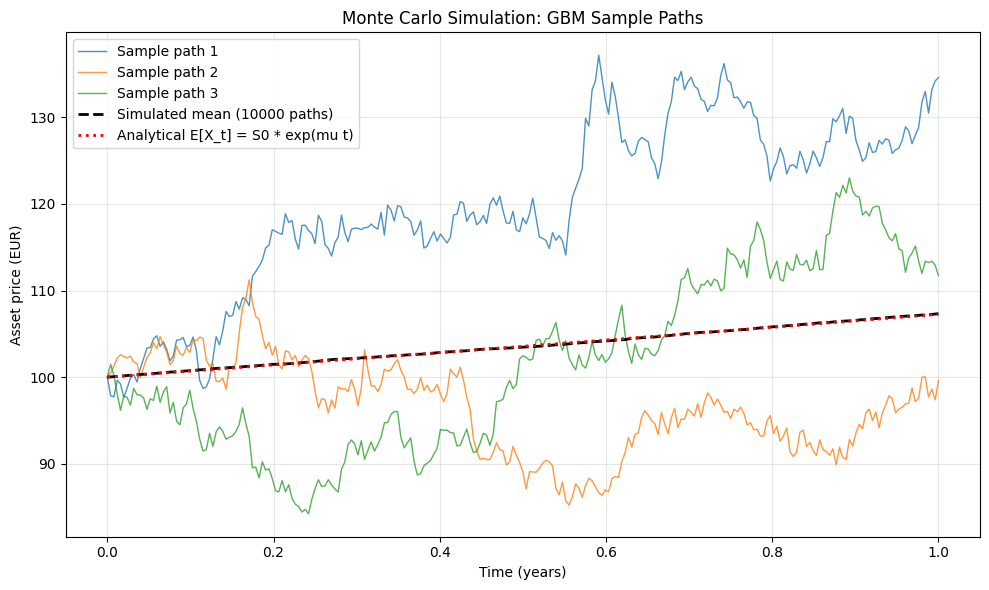

In [43]:
# Task 5.2: illustration of the Monte Carlo approach

# parameters for the illustration
S0 = 100.0              # initial stock price in EUR
MU = 0.07               # real-world drift (7%)
SIGMA = 0.20            # volatility (20%)
T = 1.0                 # one year
DT = 1 / 252            # one trading day
N_ILLUSTRATION = 10000  # many paths for a smooth mean estimate

# simulate 10000 GBM paths over one year
paths = sim_gbm(s0=S0, mu=MU, sigma=SIGMA, t_horizon=T, dt=DT,
                n_paths=N_ILLUSTRATION)
print(f"paths matrix shape (steps+1, paths): {paths.shape}")  # sanity check

time_axis = np.linspace(0, T, paths.shape[0])  # 253 time steps from 0 to T
expected_value = S0 * np.exp(MU * time_axis)  # analytical E[S_t]
simulated_mean = np.mean(paths, axis=1)  # mean across paths

print(f"after {T:.0f}y: simulated mean = {simulated_mean[-1]:.2f} EUR, "
      f"analytical = {expected_value[-1]:.2f} EUR")  # sanity check

# plotting
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(3):  # three sample paths to show GBM variability
    ax.plot(time_axis, paths[:, i], linewidth=1, alpha=0.8,
            label=f"Sample path {i + 1}")

ax.plot(time_axis, simulated_mean, color="black", linewidth=2,
        linestyle="--",
        label=f"Simulated mean ({N_ILLUSTRATION} paths)")  # empirical mean

ax.plot(time_axis, expected_value, color="red", linewidth=2,
        linestyle=":",
        label="Analytical E[X_t] = S0 * exp(mu t)")  # GBM mean

ax.set_title("Monte Carlo Simulation: GBM Sample Paths")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Asset price (EUR)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretation

The plot confirms that `sim_gbm()` is implemented correctly: the simulated
cross-sectional mean (black dashed) closely tracks the analytical
expectation $E[X_t] = S_0 \exp(\mu t)$ (red dotted).

The three individual paths show the wide range of possible outcomes under
GBM. Prices may rise strongly, fall, or stay near the start value. 
This uncertainty makes straddle valuation non-trivial and motivates the
Monte Carlo approach.


## Task 5.3: Monte Carlo valuation of the straddle

A function is implemented that prices the straddle by Monte Carlo
simulation. The logic has three steps:

1. simulate $N$ paths of the underlying with `sim_gbm()`
2. compute the straddle payoff $|S_T - K|$ at maturity for each path
3. discount the average payoff back to today:
   $\;\text{price} = e^{-rT}\, E\big[\,|S_T - K|\,\big]$



In [44]:
# Task 5.3: Monte Carlo pricing function


def price_straddle(s0, k, r, sigma, t_horizon, dt, n_paths):
    """
    Price a European straddle by Monte Carlo simulation.

    s0        : initial stock price
    k         : strike price
    r         : risk-free rate (used as drift and discount rate)
    sigma     : annual volatility
    t_horizon : time horizon in years
    dt        : length of one time step in years
    n_paths   : number of simulated paths

    Returns the straddle premium (discounted expected payoff).
    """
    # use risk-neutral drift r for no-arbitrage pricing
    paths = sim_gbm(s0=s0, mu=r, sigma=sigma, t_horizon=t_horizon,
                    dt=dt, n_paths=n_paths)

    s_t = paths[-1]                 # terminal prices at maturity
    payoffs = np.abs(s_t - k)       # straddle payoff per path at maturity

    mean_payoff = np.mean(payoffs)  # expected payoff across paths
    discount_factor = np.exp(-r * t_horizon)  # present-value discounting
    price = discount_factor * mean_payoff  # discounted straddle premium

    return price




## Task 5.4: Straddle valuation with specific parameters

The pricing function is applied to a concrete, economically plausible setup
for a German large-cap equity (comparable to a DAX stock).

Under the risk-neutral measure the drift of the underlying equals the
risk-free rate $r$. The real-world drift $\mu$ from Task 5.2 is therefore
not part of the valuation: a fair price must not depend on individual return 
expectations.

| Parameter | Value | Note |
|-----------|-------|---------------|
| $S_0$ | 100 EUR | normalised at-the-money spot price |
| $K$ | 100 EUR | strike = spot, i.e. at-the-money straddle |
| $\sigma$ | 20 % | illustrative volatility for a German large-cap equity |
| $r$ | 2.0 % | ECB deposit facility rate, Feb 2026 (EUR risk-free proxy) |
| $T$ | 1.0 | one-year option maturity |
| $dt$ | 1/252 | 252 as standard approximation |
| $N$ | 100,000 | large path count for a stable Monte Carlo estimate |

*Zero dividends assumed. Under a continuous dividend yield $q$ the risk-neutral drift would be $r - q$ instead of $r$.*


In [45]:
# Task 5.4: apply the pricing function to specific parameters

# model parameters
S0 = 100.0        # spot in EUR (at-the-money)
K = 100.0         # strike (= spot)
SIGMA = 0.20      # volatility
R = 0.02          # risk-free rate
T = 1.0           # 1 year
DT = 1 / 252      # one trading day
N_PATHS = 100000  # number of paths

np.random.seed(100)  # reproducibility

straddle_price = price_straddle(
    s0=S0, k=K, r=R, sigma=SIGMA, t_horizon=T, dt=DT,
    n_paths=N_PATHS)  # Monte Carlo straddle price

print(f"Monte Carlo straddle price: {straddle_price:.4f} EUR")  # result


Monte Carlo straddle price: 15.8187 EUR


break-even points: 84.18 EUR (lower) and 115.82 EUR (upper)


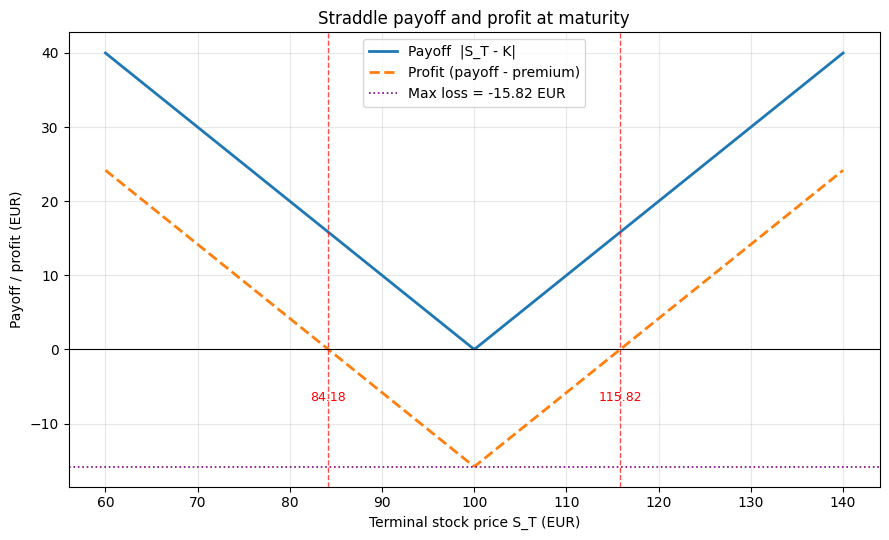

In [46]:

# Task 5.4: payoff and profit diagram of the straddle

s_grid = np.linspace(60, 140, 400)      # price grid around strike

payoff = np.abs(s_grid - K)             # straddle payoff
profit = payoff - straddle_price        # net profit after premium

lower_be = K - straddle_price           # lower break-even point
upper_be = K + straddle_price           # upper break-even point

print(f"break-even points: {lower_be:.2f} EUR (lower) "
      f"and {upper_be:.2f} EUR (upper)")

fig, ax = plt.subplots(figsize=(9, 5.5))  # figure and axis for plotting
ax.plot(s_grid, payoff, linewidth=2,
        label="Payoff  |S_T - K|")  # payoff curve
ax.plot(s_grid, profit, linewidth=2, linestyle="--",
        label="Profit (payoff - premium)")  # profit curve
ax.axhline(0, color="black", linewidth=0.8)  # break-even line at zero profit
ax.axhline(-straddle_price, color="purple", linewidth=1.2, linestyle=":",
           label=f"Max loss = -{straddle_price:.2f} EUR")  # maximum loss line

for be in (lower_be, upper_be):          # mark both break-even points
    ax.axvline(be, color="red", linewidth=1, linestyle="--", alpha=0.7)
    ax.annotate(f"{be:.2f}", xy=(be, 0), xytext=(be, -7),
                ha="center", color="red", fontsize=9)  # label below zero

ax.set_title("Straddle payoff and profit at maturity")
ax.set_xlabel("Terminal stock price S_T (EUR)")
ax.set_ylabel("Payoff / profit (EUR)")
ax.legend(loc="upper center")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Diagnostic plots

The two histograms below serve as sanity checks for the simulation.
The left plot shows the distribution of simulated terminal prices $S_T$
against the theoretical log-normal density. The right plot shows the
resulting straddle payoffs $|S_T - K|$.

mean S_T = 101.95 EUR (expected 102.02)
mean payoff |S_T - K| = 16.14 EUR


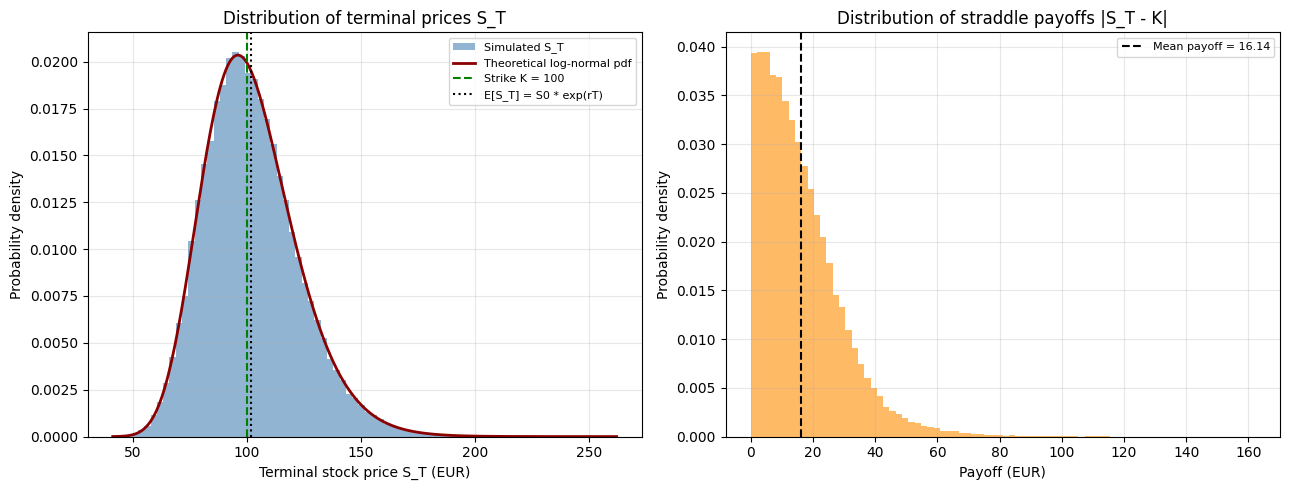

In [47]:
# Task 5.4: simulated terminal prices and payoffs

np.random.seed(100)  # reproducibility
paths = sim_gbm(s0=S0, mu=R, sigma=SIGMA, t_horizon=T, dt=DT,
                n_paths=N_PATHS)
s_t = paths[-1]         # terminal prices at maturity
payoffs = np.abs(s_t - K)  # straddle payoff per path

print(f"mean S_T = {s_t.mean():.2f} EUR "
      f"(expected {S0 * np.exp(R * T):.2f})")  # drift check
print(f"mean payoff |S_T - K| = {payoffs.mean():.2f} EUR")  # mean payoff

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))  # two subplots

# left plot: terminal prices + theoretical log-normal density
ax1.hist(s_t, bins=80, density=True, alpha=0.6, color="steelblue",
         label="Simulated S_T")  # simulated terminal prices
x = np.linspace(s_t.min(), s_t.max(), 300)  # price range for curve
m = np.log(S0) + (R - 0.5 * SIGMA ** 2) * T  # log-normal mean
sd = SIGMA * np.sqrt(T)                        # log-normal standard deviation
pdf = (1 / (x * sd * np.sqrt(2 * np.pi))
       * np.exp(-(np.log(x) - m) ** 2 / (2 * sd ** 2)))  # pdf
ax1.plot(x, pdf, color="darkred", linewidth=2,
         label="Theoretical log-normal pdf")  # benchmark density
ax1.axvline(K, color="green", linestyle="--",
            label="Strike K = 100")  # strike price
ax1.axvline(S0 * np.exp(R * T), color="black", linestyle=":",
            label="E[S_T] = S0 * exp(rT)")  # analytical expectation
ax1.set_title("Distribution of terminal prices S_T")
ax1.set_xlabel("Terminal stock price S_T (EUR)")
ax1.set_ylabel("Probability density")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# right plot: straddle payoffs
ax2.hist(payoffs, bins=80, density=True, alpha=0.6,
         color="darkorange")  # payoff distribution
ax2.axvline(np.mean(payoffs), color="black", linestyle="--",
            label=f"Mean payoff = {np.mean(payoffs):.2f}")  # mean payoff
ax2.set_title("Distribution of straddle payoffs |S_T - K|")
ax2.set_xlabel("Payoff (EUR)")
ax2.set_ylabel("Probability density")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The Monte Carlo simulation yields a straddle price of about **15.82 EUR**
on a 100 EUR stock: an investor has to pay roughly 15.82 EUR today to enter the
position.

The straddle becomes profitable only if the terminal price moves further
than the premium away from the strike $K = 100$ EUR:

- lower break-even $= K - \text{premium} = 100 - 15.82 = 84.18$ EUR
- upper break-even $= K + \text{premium} = 100 + 15.82 = 115.82$ EUR

Outside the range $[84.18,\ 115.82]$ the position pays off net of the
premium; inside it expires at a loss. This is the core property of a
straddle: a bet on a sufficiently large price move, not on its direction.

The break-even points above follow the standard undiscounted payoff-diagram convention. In Task 5.5, where all cash flows are expressed in present value, the effective break-even band widens slightly to $K \pm \text{premium} \cdot e^{rT}$.

With $N = 100{,}000$ paths the Monte Carlo simulation error is below $0.05$ EUR — well within the rounding of the reported price.


## Task 5.5: 1-, 2- and 5-year forward Value-at-Risk

As a forward-looking risk proxy, the **Value-at-Risk (VaR)** of the long
straddle is estimated for horizons of 1, 2 and 5 years. For each horizon a
straddle of that maturity is priced (risk-neutral, drift $r$) and held to
maturity. Both legs are expressed in today's euros — the terminal payoff
is discounted back — so the profit or loss is

$$e^{-rT}\,|S_T - K| - \text{premium},$$

the present value of the payoff minus the premium paid today. Comparing an
undiscounted payoff at $T$ with a premium paid today would mix euros of
different dates.

The VaR at confidence level $c$ is the loss that is not exceeded with
probability $c$,

$$P(\text{loss} \le \text{VaR}_c) = c,$$

estimated from the empirical quantile of the simulated P&L. A defining feature
of the long straddle is that its loss is bounded by the premium: the worst
case is $S_T = K$, where both legs expire worthless and the discounted payoff
is zero.

**Choice of drift:** the premium is computed risk-neutrally (drift $r$,
Tasks 5.3–5.4), but the loss distribution uses the real-world drift
$\mu = 7\%$, because VaR quantifies the actual outcomes an investor faces, not
a pricing distribution.

In [48]:
# Task 5.5: parameters

S0 = 100.0          # initial stock price in EUR
K = 100.0           # strike price (at-the-money)
R = 0.02            # risk-free rate: pricing drift and discount rate
MU = 0.07           # real-world drift (7%, DAX-level: r + equity risk premium)
SIGMA = 0.20        # annual volatility
DT = 1 / 252        # one trading day in years
N_PATHS = 100000    # number of paths for stable estimates
HORIZONS = [1, 2, 5]  # VaR horizons in years


In [49]:
# Task 5.5: calculate premium, P&L and VaR for each horizon

premiums, var95_eur, var99_eur = [], [], []  # results lists (in EUR)
var95_pct, var99_pct, p_loss = [], [], []    # results lists (%)
pnl_all = {}                                 # P&L per horizon for plotting

for t_h in HORIZONS:

    # Step 1: fair premium under risk-neutral measure (drift = r)
    np.random.seed(100)  # reproducibility
    straddle_price_T = price_straddle(s0=S0, k=K, r=R, sigma=SIGMA,
                                      t_horizon=t_h, dt=DT,
                                      n_paths=N_PATHS)

    # Step 2: real-world P&L (drift = mu), discounted to today
    np.random.seed(100)  # reproducibility
    s_t = sim_gbm(s0=S0, mu=MU, sigma=SIGMA, t_horizon=t_h, dt=DT,
                  n_paths=N_PATHS)[-1]          # terminal prices
    pnl = np.exp(-R * t_h) * np.abs(s_t - K) - straddle_price_T  # P&L
    pnl_all[t_h] = pnl                          # store for plotting

    # Step 3: VaR metrics
    v95 = -np.percentile(pnl, 5)   # 95% VaR: negative 5th percentile
    v99 = -np.percentile(pnl, 1)   # 99% VaR: negative 1st percentile
    premiums.append(straddle_price_T)
    var95_eur.append(v95)
    var99_eur.append(v99)
    var95_pct.append(v95 / straddle_price_T * 100)  # VaR as % of premium
    var99_pct.append(v99 / straddle_price_T * 100)  # VaR as % of premium
    p_loss.append(np.mean(pnl < 0) * 100)           # probability of loss


In [50]:
# Task 5.5: summary table

print(f"Long straddle held to maturity (real drift mu = {MU:.0%}, "
      f"sigma = {SIGMA:.0%}); loss is capped at the premium.\n")

header = (
    "| Horizon | Premium (max loss) | 95 % VaR | 99 % VaR | "
    "P(net loss) |\n"
    "|---------|--------------------|----------|----------|-------------|"
)
rows = [f"| {t_h} y | {premiums[i]:.2f} EUR | "
        f"{var95_eur[i]:.2f} EUR ({var95_pct[i]:.0f} %) | "
        f"{var99_eur[i]:.2f} EUR ({var99_pct[i]:.0f} %) | "
        f"{p_loss[i]:.1f} % |"
        for i, t_h in enumerate(HORIZONS)]
display(Markdown("\n".join([header] + rows)))


Long straddle held to maturity (real drift mu = 7%, sigma = 20%); loss is capped at the premium.



| Horizon | Premium (max loss) | 95 % VaR | 99 % VaR | P(net loss) |
|---------|--------------------|----------|----------|-------------|
| 1 y | 15.82 EUR | 14.56 EUR (92 %) | 15.57 EUR (98 %) | 56.1 % |
| 2 y | 22.17 EUR | 20.39 EUR (92 %) | 21.81 EUR (98 %) | 54.8 % |
| 5 y | 34.50 EUR | 31.51 EUR (91 %) | 33.90 EUR (98 %) | 51.2 % |

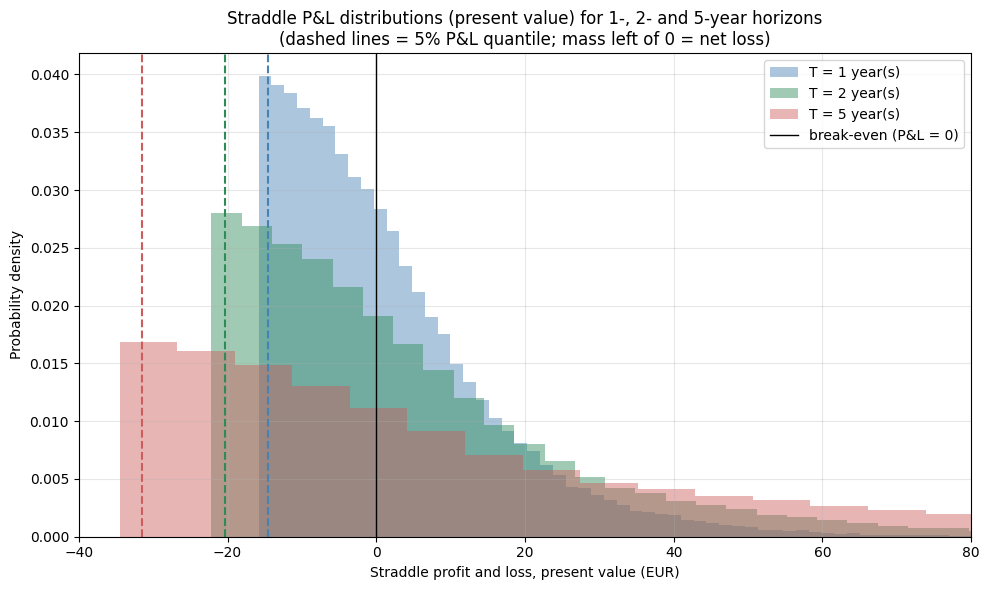

In [51]:
# Task 5.5: P&L distributions for all horizons

colors = ["steelblue", "seagreen", "indianred"]  # one color per horizon
fig, ax = plt.subplots(figsize=(10, 6))

for t_h, col in zip(HORIZONS, colors):
    pnl = pnl_all[t_h]
    ax.hist(pnl, bins=100, density=True, alpha=0.45, color=col,
            label=f"T = {t_h} year(s)")  # P&L distribution per horizon
    q05 = np.percentile(pnl, 5)
    ax.axvline(q05, color=col, linestyle="--",
               linewidth=1.5)  # 5% quantile = 95% VaR

ax.axvline(0, color="black", linewidth=1,
           label="break-even (P&L = 0)")  # zero profit line
ax.set_xlim(-40, 80)
ax.set_title("Straddle P&L distributions (present value) for 1-, 2- and "
             "5-year horizons\n(dashed lines = 5% P&L quantile; "
             "mass left of 0 = net loss)")
ax.set_xlabel("Straddle profit and loss, present value (EUR)")
ax.set_ylabel("Probability density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


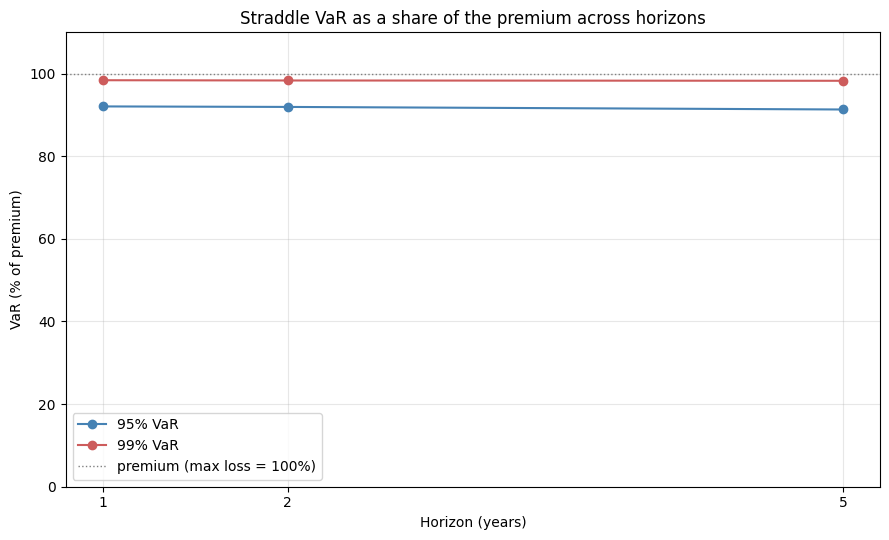

In [52]:
# Task 5.5: VaR as a share of the premium across horizons

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(HORIZONS, var95_pct, marker="o", color="steelblue",
        label="95% VaR")  # 95% VaR as % of premium
ax.plot(HORIZONS, var99_pct, marker="o", color="indianred",
        label="99% VaR")  # 99% VaR as % of premium
ax.axhline(100, color="grey", linestyle=":", linewidth=1,
           label="premium (max loss = 100%)")  # loss cap at 100%

ax.set_ylim(0, 110)  # y-axis from 0 to avoid misleading zoom
ax.set_xticks(HORIZONS)
ax.set_title("Straddle VaR as a share of the premium across horizons")
ax.set_xlabel("Horizon (years)")
ax.set_ylabel("VaR (% of premium)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Economic interpretation

The table and the two plots above describe the risk of the long straddle,
which differs fundamentally from a long equity position:

- The loss is capped at the premium. The worst case is $S_T = K$, where
  both options expire worthless and the full premium is lost. The VaR can
  therefore never exceed the premium: roughly 91–92 % of it at 95 % confidence and
  about 98 % at 99 % (the dotted line in the second plot marks the 100 % cap).
  There is no open-ended left tail. The downside is bounded by
  construction.
- VaR rises in euros mainly because the premium rises. A 5-year straddle
  simply costs more than a 1-year one, so the absolute loss is larger. As a
  fraction of the premium the VaR is nearly flat across horizons
  (~92 % / ~98 %, edging down only slightly as the horizon lengthens): the
  *relative* risk of the position barely depends on the horizon.
- A net loss is the more likely outcome. The straddle loses whenever $S_T$
  lands inside the break-even band $[K - \text{premium}\,e^{rT},\ K +
  \text{premium}\,e^{rT}]$, which happens for about 56 % of the paths at the
  one-year horizon and, with the higher real-world drift, progressively less at
  longer horizons (about 51 % at five years), as the upward drift carries more
  paths out of the band.

Economically, a long straddle is a bet on realised volatility. A high
chance of a small, bounded loss (the premium) is exchanged for a large payoff
from strong moves in *either* direction. What matters is whether the realised
move exceeds the move already priced into the premium, not the direction of
the market.

The results depend on the model assumptions: constant volatility and
lognormal returns are assumed. In practice, large price jumps and volatility
clustering can occur, which are not captured here but would increase the
straddle payoff.